In [2]:
from dataset.datasets import RandomLongitudinalDataset, AllPairsLongitudinalDataset
pair_ids = [i // 4 for i in range(48 * 4)]
dataset = AllPairsLongitudinalDataset('/home/yhchoi/EEG_Data/Create_L_NL_Control/experiment_2/before_embeddings_lecanemab.npy', '/home/yhchoi/EEG_Data/Create_L_NL_Control/experiment_2/after_embeddings_lecanemab.npy', subject_ids=pair_ids)

In [ ]:
# Assuming your dataset has a list of patient IDs corresponding to each sample


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 14,
 14,
 14,
 14,
 14,
 14,
 14,
 14,


Running t-SNE (this may take a minute)...


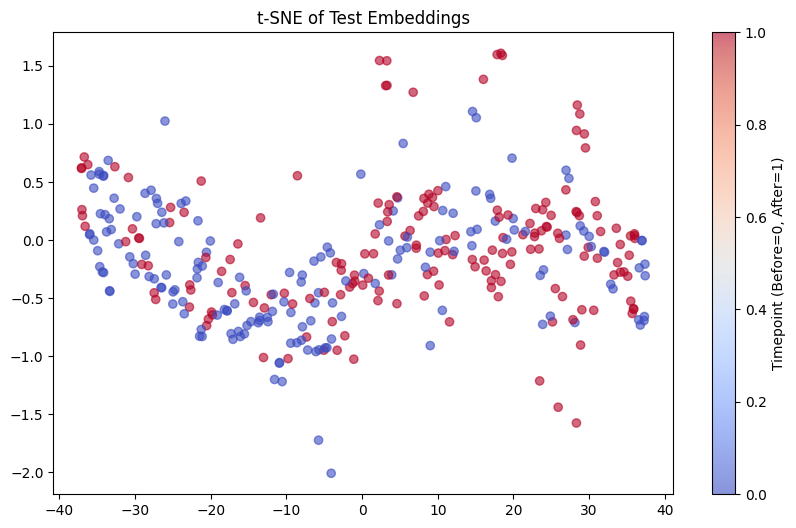

In [17]:
from dataset.datasets import RandomLongitudinalDataset, AllPairsLongitudinalDataset
from models.models import LILIE

import torch.utils
import lightning as L
from torch.utils.data import DataLoader
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Load the Model from Checkpoint
checkpoint_path = "/home/yhchoi/EEG_Data/Create_L_NL_Control/exp_pl/eeg_experiment/version_18/checkpoints/best-eeg-epoch=54-val_auroc=0.67.ckpt"
model = LILIE.load_from_checkpoint(checkpoint_path, input_dim=256, embedding_size=256, num_classes=2, pool_method="Attentive", clf_method="Linear")
model.eval()
model.freeze() # Turn off dropout/batchnorm updates
model.to('cuda')

samples_per_patient = 4
pair_ids = [i // samples_per_patient for i in range(48 * 4)]

subject_ids_4 = [1290972, 1290972, 1290972, 1290972, 1391736, 1391736, 1391736, 1391736, 1621015, 1621015, 1621015, 1621015, 1925754, 1925754, 1925754, 1925754, 20046947, 20046947, 20046947, 20046947, 20046947, 20046947, 20046947, 20046947, 20078516, 20078516, 20078516, 20078516, 20118630, 20118630, 20118630, 20118630, 20134679, 20134679, 20134679, 20134679, 2256166, 2256166, 2256166, 2256166, 2676587, 2676587, 2676587, 2676587, 2950427, 2950427, 2950427, 2950427, 2958837, 2958837, 2958837, 2958837, 309480, 309480, 309480, 309480, 3450576, 3450576, 3450576, 3450576, 3753849, 3753849, 3753849, 3753849, 382566, 382566, 382566, 382566, 475077, 475077, 475077, 475077, 520029, 520029, 520029, 520029, 5328122, 5328122, 5328122, 5328122, 5328122, 5328122, 5328122, 5328122, 6066494, 6066494, 6066494, 6066494, 6207136, 6207136, 6207136, 6207136, 6207136, 6207136, 6207136, 6207136, 622588, 622588, 622588, 622588, 6264731, 6264731, 6264731, 6264731, 6434045, 6434045, 6434045, 6434045, 6537579, 6537579, 6537579, 6537579, 6603372, 6603372, 6603372, 6603372, 6804555, 6804555, 6804555, 6804555, 6869574, 6869574, 6869574, 6869574, 6869574, 6869574, 6869574, 6869574, 6894993, 6894993, 6894993, 6894993, 6894993, 6894993, 6894993, 6894993, 6908730, 6908730, 6908730, 6908730, 6908730, 6908730, 6908730, 6908730, 830639, 830639, 830639, 830639, 8596341, 8596341, 8596341, 8596341, 9107603, 9107603, 9107603, 9107603, 9168177, 9168177, 9168177, 9168177, 9244082, 9244082, 9244082, 9244082, 9244082, 9244082, 9244082, 9244082, 9246548, 9246548, 9246548, 9246548, 9385345, 9385345, 9385345, 9385345, 9418325, 9418325, 9418325, 9418325, 9469406, 9469406, 9469406, 9469406, 947920, 947920, 947920, 947920, 947920, 947920, 947920, 947920]
subject_ids = []
for i, id in enumerate(subject_ids_4):
    if i % 4 == 0:
        subject_ids = subject_ids + [id] * 16

dataset = AllPairsLongitudinalDataset('/home/yhchoi/EEG_Data/Create_L_NL_Control/experiment_2/before_embeddings_lecanemab.npy', 
                                        '/home/yhchoi/EEG_Data/Create_L_NL_Control/experiment_2/after_embeddings_lecanemab.npy', 
                                        subject_ids=pair_ids)

from sklearn.model_selection import GroupShuffleSplit

# 2. Split indices such that the same patient is never in both sets
gss = GroupShuffleSplit(n_splits=1, train_size=0.6, random_state=42)
train_idx, test_idx = next(gss.split(X=range(len(dataset)), groups=subject_ids))

# 3. Create subsets using torch.utils.data.Subset
train_dataset = torch.utils.data.Subset(dataset, train_idx)
test_dataset = torch.utils.data.Subset(dataset, test_idx)

train_patients = [dataset.subject_id_map[i] for i in train_idx]
val_patients = [dataset.subject_id_map[i] for i in test_idx]

tt = [subject_ids[i * 16] for i in train_patients]
vv = [subject_ids[i * 16] for i in val_patients]

# 2. Extract Embeddings and Labels for Visualization
all_embeddings = []
all_subject_ids = []
all_labels = []

test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=4
)

# We use the test_loader you defined earlier
with torch.no_grad():
    for x_0, x_1, labels in test_loader:
        # Get the representation from your model's encoder
        # Adjust 'forward_encoder' to whatever your internal method is called
        x_0 = x_0.to('cuda')
        x_1 = x_1.to('cuda')
        emb_0 = model.get_embeddings(x_0, x_1)
        
        all_embeddings.append(emb_0.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# Convert to arrays
all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# 3. t-SNE Visualization
print("Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=all_labels, cmap='coolwarm', alpha=0.6)
plt.colorbar(scatter, label='Timepoint (Before=0, After=1)')
plt.title("t-SNE of Test Embeddings")
plt.show()

In [14]:
tt

[1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1290972,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 1925754,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20046947,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 20118630,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2256166,
 2

In [12]:
vv

[12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 16,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 24,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 32,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 48,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 68,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 76,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 104,
 104,
 104,
 104,
